# Learning Probability Density Functions using Non-Linear Transformation

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Dataset

The dataset used is the India Air Quality dataset.  
The feature selected for analysis is NO2 concentration.

Missing values are removed before further processing.


In [24]:
df = pd.read_csv("/india_air_quality.csv", encoding="latin1")
print(df.columns)

x = df["no2"].dropna().values
print("Number of NO2 samples: ", len(x))

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')
Number of NO2 samples:  419509


/tmp/ipython-input-1254519292.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/india_air_quality.csv", encoding="latin1")


## Non-linear Transformation

Each NO2 value x is transformed into z using:

z = x + a_r sin(b_r x)

where:

a_r = 0.05 (r mod 7)  
b_r = 0.3 (r mod 5 + 1)  

and r is roll number.

In [25]:
r = 102303764
a_r = 0.05 * (r % 7)
b_r = 0.3 * (r % 5 + 1)

print("a_r = ", a_r)
print("b_r = ", b_r)

a_r =  0.15000000000000002
b_r =  1.5


In [26]:
z = x + a_r * np.sin(b_r * x)
print("First 10 transformed values (z): ")
print(z[:10])

First 10 transformed values (z): 
[17.52349995  6.86804564 28.35851188 14.69117738  7.3548288  25.81277994
 17.17417491  8.76974931 23.00862312  9.00587824]


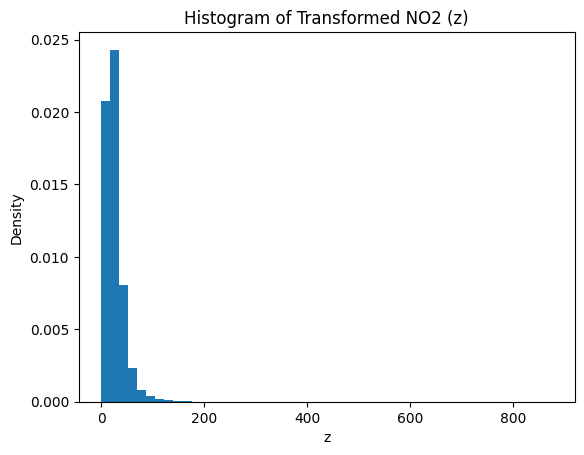

In [27]:
plt.hist(z, bins=50, density=True)
plt.title("Histogram of Transformed NO2 (z)")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()

## Probability Density Function Model

The transformed data z is modeled using:

p̂(z) = c exp(-λ (z - μ)²)

where:

μ is the center of the distribution  
λ controls the spread  
c is a scaling constant


In [28]:
def pdf_model(z, lam, mu, c):
    return c * np.exp(-lam * (z - mu)**2)

In [29]:
hist_vals, bin_edges = np.histogram(z, bins=50, density=True)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

## Parameter Estimation using Curve Fitting

The parameters λ, μ, and c are estimated by fitting the PDF model to the empirical PDF obtained from a histogram of the transformed data.
Non-linear least squares curve fitting is used to find the parameters that best match the histogram.

In [30]:
initial_guess = [0.1, np.mean(z), 1.0]
params, covariance = curve_fit(pdf_model, bin_centers, hist_vals, p0=initial_guess)

lam_est, mu_est, c_est = params
print("Estimate lambda: ", lam_est)
print("Estimated mu: ", mu_est)
print("Estimated c: ", c_est)

Estimate lambda:  0.1
Estimated mu:  25.814687284943872
Estimated c:  0.024841641057326256


/tmp/ipython-input-245692211.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(pdf_model, bin_centers, hist_vals, p0=initial_guess)


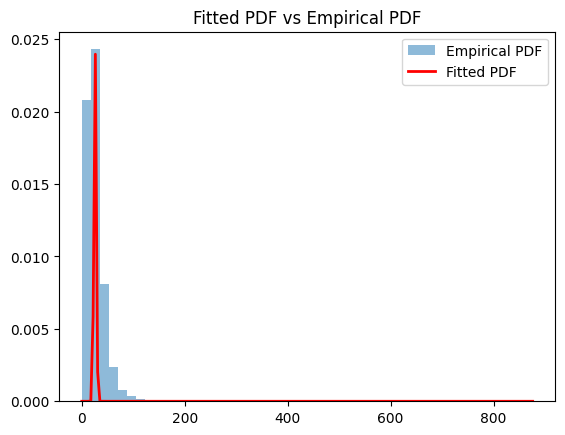

In [31]:
z_fit = np.linspace(min(z), max(z), 200)
p_fit = pdf_model(z_fit, lam_est, mu_est, c_est)

plt.hist(z, bins=50, density=True, alpha=0.5, label="Empirical PDF")
plt.plot(z_fit, p_fit, 'r-', linewidth=2, label="Fitted PDF")
plt.legend()
plt.title("Fitted PDF vs Empirical PDF")
plt.show()